In [3]:
# 1. Import libraries
import os, random, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)

In [4]:
# Seed = 42

seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.keras.utils.set_random_seed(seed)

print("Seed fixed:", seed)

Seed fixed: 42


In [5]:
# Import dataset

df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df.columns = df.columns.str.strip()




In [6]:
# Target

target = "Conversion"

In [7]:
# DROP USELESS / LEAKAGE

df = df.drop(columns=["CustomerID", "ConversionRate"], errors="ignore")

In [8]:
# DEFINE FEATURES
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

if target in numerical_cols:
    numerical_cols.remove(target)

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']
Numerical: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


In [10]:
# 3. SPLIT (70 / 15 / 15)
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (5600, 17)
Val: (1200, 17)
Test: (1200, 17)


In [11]:
# 4. ENCODE CATEGORICAL
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le


In [12]:
# 5. SCALE NUMERICAL (NO LEAKAGE)
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])



In [13]:
# 6. BUILD MODEL
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model

inputs = []
embeddings = []

In [14]:
# CATEGORICAL EMBEDDINGS
for col in categorical_cols:
    inp = Input(shape=(1,), name=col)

    vocab_size = X_train[col].nunique() + 1
    embed_dim = min(50, vocab_size // 2)

    emb = Embedding(vocab_size, embed_dim)(inp)
    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

In [15]:
# NUMERICAL INPUT
num_input = Input(shape=(len(numerical_cols),), name="numerical")
inputs.append(num_input)


In [16]:
# CONCAT
x = Concatenate()(embeddings + [num_input])

In [17]:
# MLP
x = BatchNormalization()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Gender (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignChannel     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignType        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingPlatform │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingTool     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 1)      │          3 │ Gender[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 3)      │         18 │ CampaignChannel[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 2)      │         10 │ CampaignType[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 1)      │          2 │ AdvertisingPlatf… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 1)      │          2 │ AdvertisingTool[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1)         │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 3)         │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2)         │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 1)         │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 1)         │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical           │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 20)        │          0 │ flatten_5[0][0],  │
│ (Concatenate)       │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ numerical[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,172 (51.45 KB)

 Trainable params: 13,132 (51.30 KB)

 Non-trainable params: 40 (160.00 B)

In [18]:
# 7. PREPARE INPUT DICT
def prepare_inputs(X):
    data = {col: X[col].values for col in categorical_cols}
    data["numerical"] = X[numerical_cols].values
    return data

train_inputs = prepare_inputs(X_train)
val_inputs = prepare_inputs(X_val)
test_inputs = prepare_inputs(X_test)


In [19]:
# 8. TRAIN
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8696 - loss: 0.3774 - val_accuracy: 0.8767 - val_loss: 0.3434
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8813 - loss: 0.3226 - val_accuracy: 0.8842 - val_loss: 0.3376
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8850 - loss: 0.3173 - val_accuracy: 0.8833 - val_loss: 0.3348
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8871 - loss: 0.3111 - val_accuracy: 0.8850 - val_loss: 0.3305
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8833 - val_loss: 0.3301
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8884 - loss: 0.3015 - val_accuracy: 0.8867 - val_loss: 0.3279
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8907 - loss: 0.2954 - val_accuracy: 0.8833 - val_loss: 0.3293
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8929 - loss: 0.2930 - val_accuracy: 0.

In [20]:
# 9. EVALUATE
y_pred_prob = model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("F1:", f1_score(y_test, y_pred))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
AUC: 0.7463904018086527
F1: 0.936247723132969


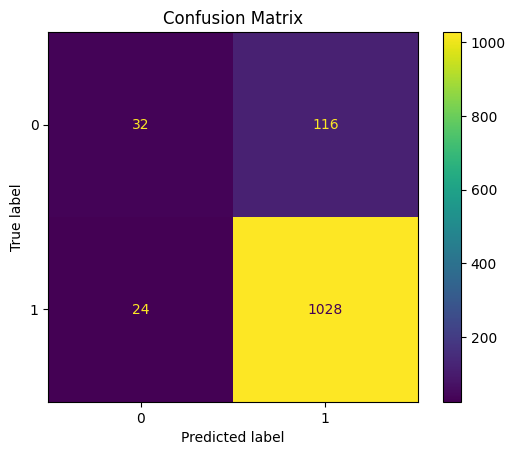

In [21]:
# 10. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()


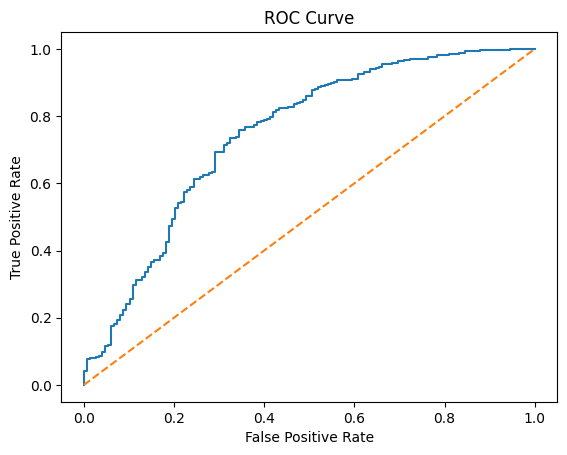

In [22]:
# 11. ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


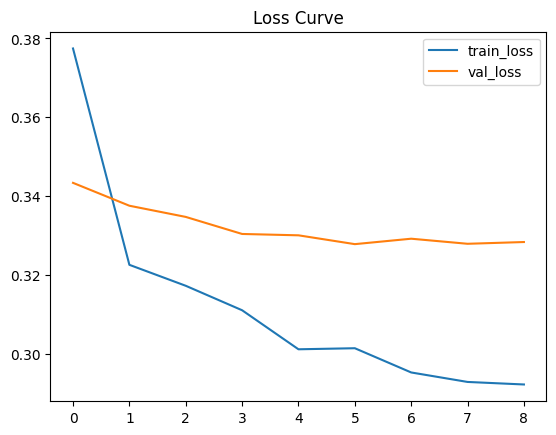

In [23]:
# 12. TRAINING CURVES
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()